<a href="https://colab.research.google.com/github/devarsh3453/NEW/blob/main/Z_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
df=pd.read_csv("/content/sample_data/california_housing_test.csv")

In [60]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB


In [62]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


In [63]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [64]:
mean=df['population'].mean()
std1=df['population'].std()


In [65]:

df['new']=(df['population']-mean)/std1

In [66]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,new
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0,0.130224
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0,-0.576200
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0,0.078795
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0,-1.313675
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0,-0.536415
...,...,...,...,...,...,...,...,...,...,...
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0,-0.140507
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0,2.031163
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0,-0.688762
2998,-117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0,-1.316586


In [80]:
min=float(mean-3*std1)
max=float(mean+3*std1)
type(min)
max
min

-1688.83037057006

In [68]:
df[(df['population'] > max) | (df['population'] < min)].shape

(46, 10)

In [69]:
df[(df['new']>3) | (df['new']<-3)].shape

(46, 10)

#Trimming

In [70]:
df_trimm=df[(df['new']<3) & (df['new']>-3)]
df_trim1=df[(df['population']<max) & (df['population']>min)]

In [71]:
df.shape
df_trim1.shape
df_trim1==df_trimm

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,new
0,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...
2995,True,True,True,True,True,True,True,True,True,True
2996,True,True,True,True,True,True,True,True,True,True
2997,True,True,True,True,True,True,True,True,True,True
2998,True,True,True,True,True,True,True,True,True,True


#Capping

In [72]:
df['population_capped']=np.where(
    df['population']>max,
    max,
    np.where(
        df['population']<min,
        min,
        df['population']
    )
)
#  np.where(condition,statement 1,statement 2)  if condition is true than statement 1 is executed else statement 2 is executed

In [79]:
df[['population_capped','population']].describe()

,population_capped,population
count,3000.000000,3000.000000
mean,1373.943558,1402.798667
std,881.245151,1030.543012
min,5.000000,5.000000
25%,780.000000,780.000000
50%,1155.000000,1155.000000
75%,1742.750000,1742.750000
max,4494.427704,11935.000000


In [97]:
import seaborn as sns

from sklearn.preprocessing import StandardScaler,FunctionTransformer

In [102]:
trf=FunctionTransformer(func=np.log1p)
ndf=trf.fit_transform(df[['median_income']])

/tmp/ipykernel_529/3590638613.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ndf['median_income'])


<Axes: xlabel='median_income', ylabel='Density'>

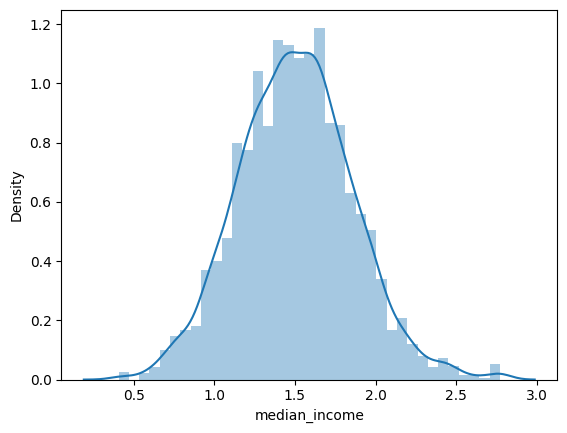

In [103]:
sns.distplot(ndf['median_income'])

In [108]:
nmin=ndf['median_income'].min()
nmax=ndf['median_income'].max()
nstd=ndf['median_income'].std()
nmin

0.40539843921917673

In [110]:
ndf['median_income']=np.where(
    ndf['median_income']>nmax,
    nmax,
    np.where(
        ndf['median_income']<nmin,
        nmin,
        ndf['median_income']
    )
)
nmax
ndf.shape

(3000, 1)

In [111]:
ndf.describe()

,median_income
count,3000.000000
mean,1.505237
std,0.355671
min,0.405398
25%,1.265256
50%,1.501218
75%,1.732801
max,2.772595
